# Qiskit Statevector Benchmark for 1D Fermi-Hubbard dynamics

In the following we will be going through an exact reference simulation (up to Trotter error) is implemented of the same 1D Fermi-Hubbard model studied in 'chainmajorana.ipynb'.\
While the MP method is an approximation, here an exact method is implemented using the Qiskit Aer statevector simulator for reference purposes.[1]\
This was done similar to the approach in 'kagomebenchmark.ipynb', so it would be appropriate to go through that notebook too. 


In [ ]:
try:
    from spd.SparsePauliDynamics import *
    from spd.BaseOperatorRepresentation import * 
except ImportError:
    print("\n" + "="*60)
    print("REQUIRED PACKAGE 'spd' NOT FOUND")
    print("="*60)
    print("This notebook relies on the 'spd' package.")
    print("Please install it before proceeding:\n")
    print("   pip install git+https://github.com/tbegusic/spd.git")
    print("="*60 + "\n")
    raise
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit_aer import AerSimulator

In [ ]:
L = 4                   
t = 1.0
U = 1.0
dt = 0.12                   
T = 6.0                     
nsteps = int(T / dt)         

threshold = 1e-5


nmodes = 2 * L

nlist = [(i, i+1) for i in range(L-1)]

In [ ]:
ham = FermionicOp({}, nmodes)


for i, j in nlist:
    up_i = 2 * i
    up_j = 2 * j
    ham_hop += FermionicOp({f'+_{up_i} -_{up_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{up_j} -_{up_i}': -t}, num_spin_orbitals=nmodes)
    down_i = 2 * i + 1
    down_j = 2 * j + 1
    ham_hop += FermionicOp({f'+_{down_i} -_{down_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{down_j} -_{down_i}': -t}, num_spin_orbitals=nmodes)


for site in range(L):
    up_idx = 2 * site
    down_idx = 2 * site + 1
    n_up = FermionicOp({f'+_{up_idx} -_{up_idx}': 1}, num_spin_orbitals=nmodes)
    n_down = FermionicOp({f'+_{down_idx} -_{down_idx}': 1}, num_spin_orbitals=nmodes)
    ham_rep += U * n_up @ n_down



In [ ]:
mapper = JordanWignerMapper()

ham_mapped = mapper.map(ham_hop) + mapper.map(ham_rep)

central = 2             
obs_up_idx = 2 * central
obs_ferm = FermionicOp({f'+_{obs_up_idx} -_{obs_up_idx}': 1}, num_spin_orbitals=nmodes)
obs = mapper.map(obs_ferm)


In [39]:
qc = QuantumCircuit(nmodes)

for site in range(L):
    if site %2 == 0:
        qc.x(2*site+1)
    else :
        qc.x(2*site)

qc.save_statevector(label='psi_0')

for step in range(nsteps):
    evo = PauliEvolutionGate(ham, time=dt, synthesis=LieTrotter(reps = 1))
    qc.append(evo, range(nmodes))
    qc.save_statevector(label=f'psi_{step+1}')


In [40]:
sim = AerSimulator(method='statevector')
qc_compiled = transpile(qc, sim)
result = sim.run(qc_compiled).result()
data = result.data(0)

In [41]:
times = np.arange(nsteps + 1) * dt
exp_vals = []
for step in range(nsteps + 1):
    sv = Statevector(data[f'psi_{step}'])
    exp_val = sv.expectation_value(obs).real
    exp_vals.append(exp_val)

In [ ]:
plt.plot(times, exp_vals)
plt.show()

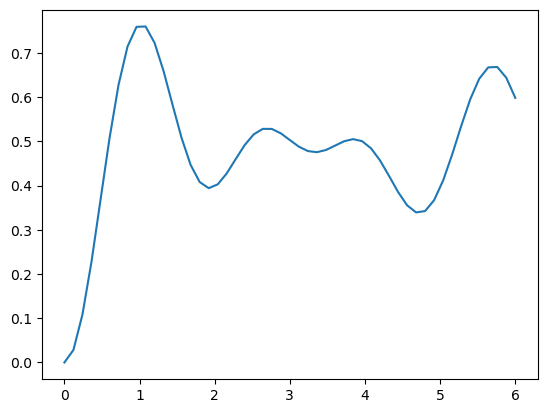

## References

[1] “AerSimulator - Qiskit Aer 0.17.1.” Accessed April 21, 2026. https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html.